In [14]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dynamic_routing_analysis import decoding_utils, data_utils, spike_utils
# from dynamic_routing_analysis import data_utils
import npc_lims
# import dynamic_routing_analysis as dra
# import pingouin as pg
import os

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
baseline_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/decode_context_baseline_500ms_all_units_strict_drift_0/"

In [3]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_good_behavior_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [17]:
sel_session='742903_2024-10-22'
baseline_decoder_coefs = decoding_utils.load_decoder_coefs(results_path=baseline_path,session_list=[sel_session]).to_pandas()



In [29]:
session_info=npc_lims.get_session_info(sel_session)
trials=data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
units=data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

#make data array

units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.1 and \
    ~structure.isna() and ~location.isna()'
    ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

time_before = 0.5
time_after = 0.01
binsize = 0.5
trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize)

742903_2024-10-22 cached trials loaded
742903_2024-10-22 cached units loaded


In [30]:
baseline_decoder_coefs

,time_aligned_to,bin_size,sliding_window_size,bin_center,repeat_idx,unit_ids,coefs,session_id,structure,unit_subsample_size,n_units,n_probes,probe
0,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_A-100, 742903_2024-10-22_A-...","[0.31430092629139395, -0.21364259386382906, 0....",742903_2024-10-22,ACAd,NaN,35,1,A
1,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_A-302, 742903_2024-10-22_A-...","[0.3174338701638574, -0.11274377956559131, 0.0...",742903_2024-10-22,ACAv,NaN,25,1,A
2,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_C-10, 742903_2024-10-22_C-1...","[0.12762845648474405, 0.3017030302280593, -0.3...",742903_2024-10-22,CP,NaN,46,1,C
3,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_B-22, 742903_2024-10-22_B-2...","[0.09842970186693667, 0.25049058389881373, -0....",742903_2024-10-22,GU,NaN,39,1,B
4,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_F-10, 742903_2024-10-22_F-1...","[0.005146173207660509, 0.21280230718795465, -0...",742903_2024-10-22,ILA,NaN,109,1,F
5,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_A-0, 742903_2024-10-22_A-10...","[-0.045091517740346025, 0.6404395515356119, -0...",742903_2024-10-22,LSr,NaN,30,1,A
6,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_A-130, 742903_2024-10-22_A-...","[0.5386436952237867, -0.6683601126377485, 0.43...",742903_2024-10-22,MOs,NaN,242,3,AEF
7,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_E-1073, 742903_2024-10-22_E...","[-0.19825184593067988, 0.452165767891772, 0.0,...",742903_2024-10-22,ORBl,NaN,44,1,E
8,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_F-129, 742903_2024-10-22_F-...","[0.46801186586163046, -0.8477326563386256, -0....",742903_2024-10-22,ORBm,NaN,44,1,F
9,stim_start_time,0.5,None,-0.25,0,"[742903_2024-10-22_E-1012, 742903_2024-10-22_E...","[0.08373110845515386, -0.43037622250919405, 0....",742903_2024-10-22,ORBvl,NaN,193,1,E


In [78]:
sel_structure='MOs'

structure_decoder_coefs=baseline_decoder_coefs.query('structure==@sel_structure')

structure_unit_ids = units_filtered.query('structure==@sel_structure')['unit_id'].unique()
structure_da=trial_da.sel(unit_id=structure_unit_ids)

# sort baseline_decoder_coefs and structure_da by unit ids
structure_da=structure_da.sortby('unit_id')

decoder_unit_sort_idx = np.argsort(structure_decoder_coefs['unit_ids'].values[0])
structure_unit_ids = structure_decoder_coefs['unit_ids'].values[0][decoder_unit_sort_idx]
structure_coefs = structure_decoder_coefs['coefs'].values[0][decoder_unit_sort_idx]

if np.any(structure_da.unit_id.values != structure_unit_ids):
    raise ValueError("Unit IDs do not match between structure_da and structure_decoder_coefs")
else:
    print("Unit IDs match between structure_da and structure_decoder_coefs")



Unit IDs match between structure_da and structure_decoder_coefs


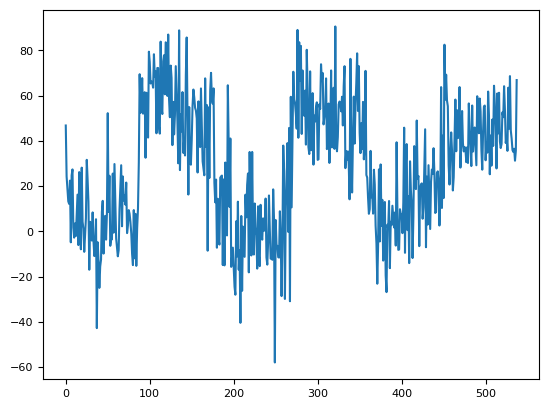

In [79]:
unit_data=structure_da.data.reshape(structure_da.data.shape[0], -1).T
projection = unit_data @ structure_coefs

fig,ax=plt.subplots(1,1)
ax.plot(projection)

In [80]:
var_projection = np.var(projection)
total_var = np.trace(np.cov(unit_data, rowvar=False))
variance_explained = var_projection / total_var

print("Variance explained by context axis:", variance_explained)

Variance explained by context axis: 0.38653236670956775


In [98]:
total_var

11718.90290959689

In [115]:
sel_structure='ORBl'
structure_unit_ids = units_filtered.query('structure==@sel_structure')['unit_id'].unique()
structure_da=trial_da.sel(unit_id=structure_unit_ids)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# X = trial_da.data.reshape(trial_da.data.shape[0], -1).T
X = structure_da.data.reshape(structure_da.data.shape[0], -1).T

y = trials['is_vis_rewarded'].values

X=scaler.fit_transform(X)

# 1. Fit logistic regression
clf = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000, class_weight='balanced',)  # no regularization for clean weights
clf.fit(X, y)

# 2. Extract the weight vector
w = clf.coef_.flatten()

# 3. Project neural data onto the context axis
z = X @ w

# 4. Compute variance explained
var_z = np.var(z)
total_var = np.trace(np.cov(X, rowvar=False))
variance_explained = var_z / total_var

print("Variance explained by context axis:", variance_explained)


Variance explained by context axis: 0.14918698222366816
